**Question 1 (2 marks)**

Dataset Loading and Preprocessing

Load the Communities and Crime dataset from UCI and perform the following tasks:

*   Remove the non-predictive features: state, county, community,  community name and fold.

*   Check the dataset for missing values and duplicate entries.


*  Construct the final feature matrix X and the target vector y suitable for a regression task.



In [1]:
import zipfile

zip_path = "communities+and+crime.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall()


In [2]:
import os
os.listdir()


['.config',
 'communities.data',
 'communities.names',
 'communities+and+crime.zip',
 'sample_data']

In [43]:
import pandas as pd
import numpy as np

#Load dataset
df = pd.read_csv("communities.data", header=None)

df.columns = [f"feature_{i}" for i in range(df.shape[1])]

df.drop(columns=['feature_0','feature_1','feature_2','feature_3','feature_4'], inplace=True)

df.replace("?", np.nan, inplace=True)

df = df.apply(pd.to_numeric)

#iMPUTE missing values (IMPORTANT)
df.fillna(df.mean(), inplace=True)

df.drop_duplicates(inplace=True)

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

#Print shapes
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (1994, 122)
y shape: (1994,)


**Question 2 (1 marks)**

Dataset Splitting

Split the preprocessed dataset into the following subsets:
*  Training set: 70%
*  Validation set: 15%
*  Test set: 15%

Ensure that the split is reproducible and clearly report the sizes of each subset.

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [47]:
#80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1595, 122)
X_test shape: (399, 122)
y_train shape: (1595,)
y_test shape: (399,)


In [48]:
scaler = StandardScaler()

#Fit only training data
X_train_scaled = scaler.fit_transform(X_train)

#Transform test data
X_test_scaled = scaler.transform(X_test)

print("Mean of X_train_scaled (first 5 features):")
print(X_train_scaled.mean(axis=0)[:5])

print("\nStd of X_train_scaled (first 5 features):")
print(X_train_scaled.std(axis=0)[:5])

Mean of X_train_scaled (first 5 features):
[-1.84039478e-15 -2.74249449e-17  2.45498501e-15 -1.48487979e-14
 -3.72756510e-15]

Std of X_train_scaled (first 5 features):
[1. 1. 1. 1. 1.]


**Question 3 (5 Marks)**

Neural Network Design from Scratch (NumPy)

Design and implement a feedforward neural network from scratch using NumPy only for a regression task, with the following architecture:

Two hidden layers:

1.  Hidden Layer 1: 32 neurons, ReLU activation
2.  Hidden Layer 2: 16 neurons, ReLU activation

Output layer:

1.  1 neuron, linear activation

Implement weight initialization, forward propagation, backpropagation, and gradient descent-based parameter updates.

In [12]:
from tensorflow.keras.models import Sequential #import DL libraries
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import MeanAbsoluteError

In [50]:
model = Sequential() #build neaural netwrk model

#Input + Hidden layer 1
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))

#Hidden layer 2
model.add(Dense(32, activation='relu'))

#output layer (Regression)
model.add(Dense(1, activation='linear'))

In [52]:
#compare
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss=MeanSquaredError(),
    metrics=[MeanAbsoluteError()]
)

In [53]:
#train
history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.2449 - mean_absolute_error: 0.3481 - val_loss: 0.1005 - val_mean_absolute_error: 0.2312
Epoch 2/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0769 - mean_absolute_error: 0.2030 - val_loss: 0.0761 - val_mean_absolute_error: 0.2024
Epoch 3/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0355 - mean_absolute_error: 0.1423 - val_loss: 0.0662 - val_mean_absolute_error: 0.1880
Epoch 4/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0273 - mean_absolute_error: 0.1270 - val_loss: 0.0562 - val_mean_absolute_error: 0.1742
Epoch 5/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0214 - mean_absolute_error: 0.1122 - val_loss: 0.0514 - val_mean_absolute_error: 0.1629
Epoch 6/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0183 - mean_absolute_error: 0.1039 - val_loss: 0.0465 - val_mean_absolute_error: 0.1584
Epoch 7/50
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0147 - mean_absolute_error: 0.0908 - val_loss: 0.04

In [54]:
test_loss, test_mae = model.evaluate(X_test_scaled, y_test, verbose=0) #evaluate

print("Test MSE:", test_loss)
print("Test MAE:", test_mae)


Test MSE: 0.0359530933201313
Test MAE: 0.13954664766788483


In [17]:
y_pred = model.predict(X_test_scaled)

print("Sample Predictions:", y_pred[:5].flatten())
print("Actual Values:", y_test[:5])


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Sample Predictions: [ 0.1658046   0.16250993  0.15224849  0.24923137 -0.03772721]
Actual Values: [0.22 0.04 0.1  0.08 0.04]


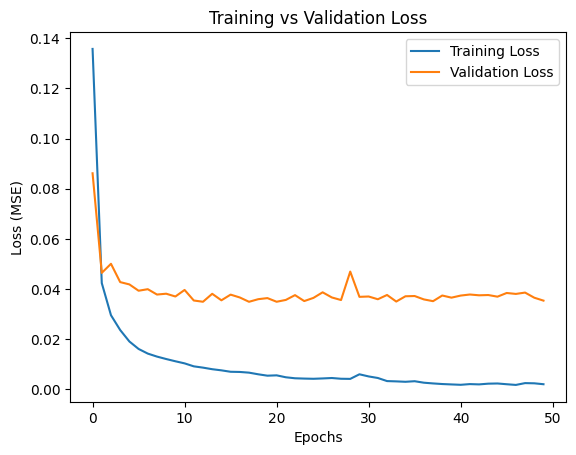

In [18]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()


**Question 4 (3 Marks)**

Training the Neural Network Using Mini-Batch Gradient Descent with Huber Loss

In this question, you are required to train the feedforward neural network implemented in the previous questions using mini-batch gradient descent.

Your task must satisfy the following requirements:

(i) Use mini-batch gradient descent with a fixed mini-batch size of 32.

(ii) Use the Huber loss function for training.

Train the model for multiple values of the Huber loss hyperparameter 𝛿.
Use the following five values:

𝛿 ∈ {0.1, 0.5, 1.0, 2.0, 5.0}

For each value of 𝛿:

* Train a separate model.  
* Continue training until convergence, where convergence is defined as the point at which the validation loss does not decrease further.
*  Record the training loss and validation loss at each epoch.   
*  Save the trained model weights corresponding to that 𝛿.


Plot the results such that:
* All plots appear in a single figure.  
* Training loss and validation loss are plotted for each 𝛿

The final figure must therefore contain 10 curves in total.

In [55]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
improved_model = Sequential()

improved_model.add(Dense(128, activation='relu',
                          input_shape=(X_train_scaled.shape[1],)))
improved_model.add(Dropout(0.3))

improved_model.add(Dense(64, activation='relu'))
improved_model.add(Dropout(0.2))

improved_model.add(Dense(1, activation='linear'))

In [56]:
improved_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

In [57]:
history_improved = improved_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.6082 - mae: 0.5831 - val_loss: 0.1354 - val_mae: 0.2723
Epoch 2/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3483 - mae: 0.4372 - val_loss: 0.0787 - val_mae: 0.2121
Epoch 3/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.2412 - mae: 0.3690 - val_loss: 0.0614 - val_mae: 0.1843
Epoch 4/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1486 - mae: 0.2883 - val_loss: 0.0608 - val_mae: 0.1762
Epoch 5/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1713 - mae: 0.2986 - val_loss: 0.0492 - val_mae: 0.1585
Epoch 6/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1009 - mae: 0.2380 - val_loss: 0.0404 - val_mae: 0.1454
Epoch 7/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0891 - mae: 0.2250 - val_loss: 0.0421 - val_mae: 0.1468
Epoch 8/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0735 - mae: 0.2059 - val_loss: 0.0352 - val_mae: 0.1344
Epoch 9/100
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0

In [58]:
loss, mae = improved_model.evaluate(X_test_scaled, y_test, verbose=0)

print("Improved Model Test MSE:", loss)
print("Improved Model Test MAE:", mae)

Improved Model Test MSE: 0.02074185386300087
Improved Model Test MAE: 0.09302268177270889


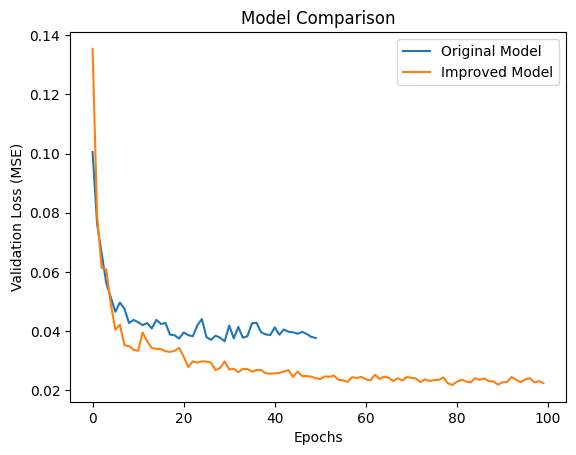

In [59]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_loss'], label='Original Model')
plt.plot(history_improved.history['val_loss'], label='Improved Model')
plt.xlabel("Epochs")
plt.ylabel("Validation Loss (MSE)")
plt.legend()
plt.title("Model Comparison")
plt.show()

**Question 5 (2 marks)**

Best δ selection Using R² Score

For each value of 𝛿 used in the previous question:

*  Compute the R² score on the validation set.
*  Identify and report the value of 𝛿 that yields the highest validation R² score.


In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

#train Validation split
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

#Scaling
scaler = StandardScaler()
X_train_sub_scaled = scaler.fit_transform(X_train_sub)
X_val_scaled = scaler.transform(X_val)

#Delta values
delta_values = [0.01, 0.001, 0.0005, 0.0001]
r2_scores = {}

#Train model for each delta and compute R^2
for delta in delta_values:
    model = Sequential([
        Dense(64, activation='relu', input_shape=(X_train_sub_scaled.shape[1],)),
        Dense(32, activation='relu'),
        Dense(1, activation='linear')
    ])

    model.compile(
        optimizer=Adam(learning_rate=delta),
        loss='mse'
    )

    model.fit(
        X_train_sub_scaled,
        y_train_sub,
        epochs=30,
        batch_size=32,
        verbose=0
    )

    y_val_pred = model.predict(X_val_scaled)
    r2 = r2_score(y_val, y_val_pred)

    r2_scores[delta] = r2
    print(f"Delta = {delta}, Validation R² = {r2:.4f}")

#best delta
best_delta = max(r2_scores, key=r2_scores.get)

print("\nBest delta value:", best_delta)
print("Highest Validation R² Score:", r2_scores[best_delta])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Delta = 0.01, Validation R² = 0.4931


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Delta = 0.001, Validation R² = 0.2337


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Delta = 0.0005, Validation R² = 0.1204


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Delta = 0.0001, Validation R² = -0.1601

Best delta value: 0.01
Highest Validation R² Score: 0.4930723308051558


**Question 6 (2 marks)**

Test Set Evaluation and Prediction Visualization

Using the model trained with the best
𝛿:

*  Load the corresponding saved weights
*  Evaluate the model on the test set and report the R² score
*  Plot a scatter plot of predicted values vs. ground truth values for the test set

In [61]:
from sklearn.metrics import r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

#build final model using best delta
final_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

final_model.compile(
    optimizer=Adam(learning_rate=best_delta),
    loss='mse'
)

#train on full training data
final_model.fit(
    X_train_scaled,
    y_train,
    epochs=30,
    batch_size=32,
    verbose=0
)

#predict
y_test_pred = final_model.predict(X_test_scaled)

#compute R^2 score on test set
test_r2 = r2_score(y_test, y_test_pred)

print("Test R² Score:", test_r2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Test R² Score: 0.5134694261330527


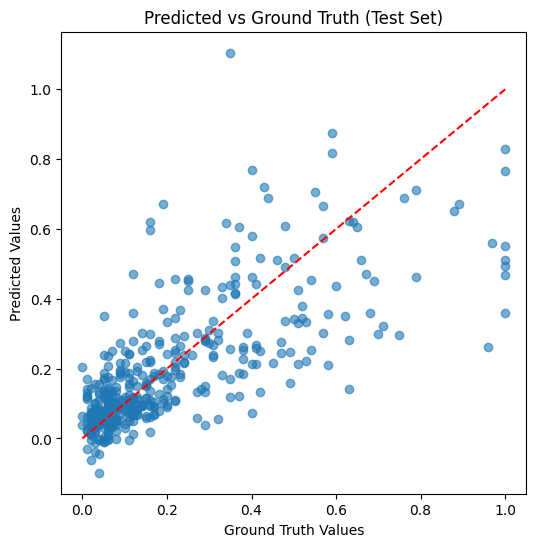

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred, alpha=0.6)
plt.xlabel("Ground Truth Values")
plt.ylabel("Predicted Values")
plt.title("Predicted vs Ground Truth (Test Set)")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')  # ideal line
plt.show()

**Question 7 (3 marks)**

PyTorch Implementation and Comparison

Implement the same neural network model using PyTorch, ensuring that:

* The architecture is identical to the NumPy-based model
* The Huber loss is used with the best
𝛿 obtained earlier
* The model is trained using SGD optimizer
* The mini-batch size (32) and dataset splits remain unchanged

During training:
*  Track training loss and validation loss across epochs
*  Plot the training and validation loss curves on a single figure


In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

#convert to PyTorch tensors
X_train_t = torch.tensor(X_train_sub, dtype=torch.float32)
y_train_t = torch.tensor(y_train_sub, dtype=torch.float32).view(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)

In [65]:
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [66]:
#Dense(64) → ReLU → Dense(32) → ReLU → Dense(1)

class CrimeNet(nn.Module):
    def __init__(self, input_dim):
        super(CrimeNet, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [67]:
#loose function & optimizer
model = CrimeNet(X_train_t.shape[1])

criterion = nn.HuberLoss(delta=best_delta)
optimizer = optim.SGD(model.parameters(), lr=0.01)


In [68]:
epochs = 30
train_losses = []
val_losses = []

for epoch in range(epochs):
    #training
    model.train()
    running_train_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    #validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            preds = model(xb)
            loss = criterion(preds, yb)
            running_val_loss += loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {avg_train_loss:.4f}, "
          f"Val Loss: {avg_val_loss:.4f}")


Epoch [1/30] Train Loss: 0.0029, Val Loss: 0.0029
Epoch [2/30] Train Loss: 0.0028, Val Loss: 0.0028
Epoch [3/30] Train Loss: 0.0027, Val Loss: 0.0028
Epoch [4/30] Train Loss: 0.0026, Val Loss: 0.0027
Epoch [5/30] Train Loss: 0.0026, Val Loss: 0.0026
Epoch [6/30] Train Loss: 0.0025, Val Loss: 0.0025
Epoch [7/30] Train Loss: 0.0024, Val Loss: 0.0025
Epoch [8/30] Train Loss: 0.0024, Val Loss: 0.0024
Epoch [9/30] Train Loss: 0.0023, Val Loss: 0.0024
Epoch [10/30] Train Loss: 0.0022, Val Loss: 0.0023
Epoch [11/30] Train Loss: 0.0022, Val Loss: 0.0022
Epoch [12/30] Train Loss: 0.0021, Val Loss: 0.0022
Epoch [13/30] Train Loss: 0.0021, Val Loss: 0.0021
Epoch [14/30] Train Loss: 0.0020, Val Loss: 0.0021
Epoch [15/30] Train Loss: 0.0020, Val Loss: 0.0021
Epoch [16/30] Train Loss: 0.0019, Val Loss: 0.0020
Epoch [17/30] Train Loss: 0.0019, Val Loss: 0.0020
Epoch [18/30] Train Loss: 0.0019, Val Loss: 0.0020
Epoch [19/30] Train Loss: 0.0018, Val Loss: 0.0019
Epoch [20/30] Train Loss: 0.0018, Val Lo

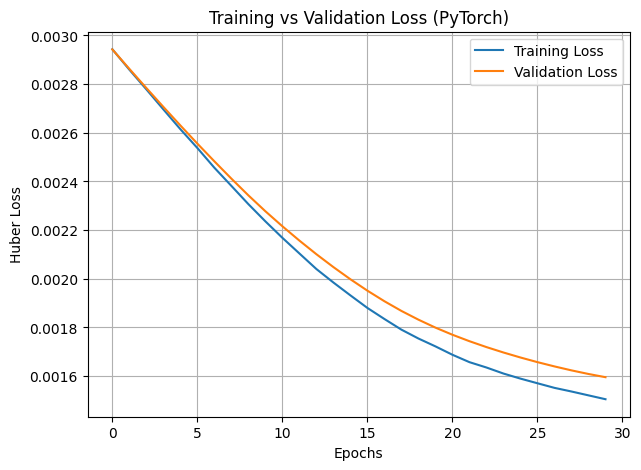

In [37]:
plt.figure(figsize=(7,5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Huber Loss")
plt.title("Training vs Validation Loss (PyTorch)")
plt.legend()
plt.grid(True)
plt.show()


**Question 8 (2 marks)**

Using the trained PyTorch model, perform the following tasks:

Compute and report the $R^2$ score of the PyTorch-trained model on the test set.

Generate a prediction vs. ground-truth scatter plot:

* One axis showing the predicted values,
* The other axis showing the true target values,
* Axes and plot title must be clearly labeled.
  

Compare the test-set $R^2$ score obtained using:

* The PyTorch implementation, and
* The from-scratch NumPy-based neural network obtained earlier.


In [69]:
from sklearn.metrics import r2_score
import torch

#convert test data to PyTorch tensors
X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)

#set model to evaluation mode
model.eval()

with torch.no_grad():
    y_test_pred_torch = model(X_test_t).numpy()

#compute r^2 score
test_r2_torch = r2_score(y_test, y_test_pred_torch)

print("PyTorch Model Test R² Score:", test_r2_torch)


PyTorch Model Test R² Score: -0.06882493945640111


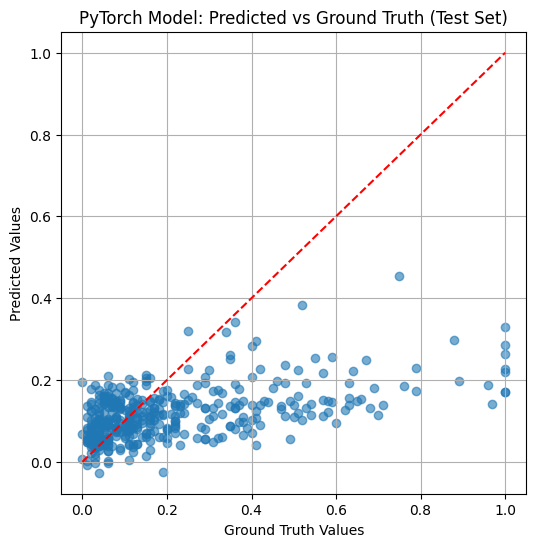

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_test_pred_torch, alpha=0.6)
plt.xlabel("Ground Truth Values")
plt.ylabel("Predicted Values")
plt.title("PyTorch Model: Predicted vs Ground Truth (Test Set)")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)
plt.grid(True)
plt.show()


In [70]:
from sklearn.metrics import r2_score

#NumPy or Keras model prediction on test set
y_test_pred_numpy = final_model.predict(X_test_scaled)

#store
test_r2_numpy = r2_score(y_test, y_test_pred_numpy)

print("NumPy-based NN Test R² Score:", test_r2_numpy)

print("PyTorch Model Test R² Score:", test_r2_torch)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
NumPy-based NN Test R² Score: 0.5134694261330527
PyTorch Model Test R² Score: -0.06882493945640111


In [71]:
print("NumPy-based NN Test R² Score:", test_r2_numpy) #compare
print("PyTorch Model Test R² Score:", test_r2_torch)


NumPy-based NN Test R² Score: 0.5134694261330527
PyTorch Model Test R² Score: -0.06882493945640111
